# GPCC Precipitation

Monthly land-surface precipitation from the Global Precipitation Climatology Centre at Deutscher
Wetterdienst, interpolated from rain gauges onto a one-degree grid and averaged here onto countries by area.
It is the only monthly series in this collection, and the only one reaching back to 1891.

## Provenance

These are the fields of the `FULL_DATA` and `MONITORING` declarations in
`climate_risk/data/gpcc.py`, which is what `fetch` reads. Check that file rather than this page if
the two ever disagree.

In [1]:
import dataclasses

from IPython.display import Markdown

from climate_risk.data.gpcc import FULL_DATA

declared = {"publisher": "Global Precipitation Climatology Centre, Deutscher Wetterdienst"} | dataclasses.asdict(
    FULL_DATA.sources[0]
)

rows = [f"| {field} | {value} |" for field, value in declared.items()]

Markdown("\n".join(["| Field | Value |", "|---|---|", *rows]))

| Field | Value |
|---|---|
| publisher | Global Precipitation Climatology Centre, Deutscher Wetterdienst |
| url | https://opendata.dwd.de/climate_environment/GPCC/full_data_monthly_v2022/10/full_data_monthly_v2022_1891_1900_10.nc.gz |
| filename | full_data_monthly_v2022_1891_1900_10.nc.gz |
| license | CC BY 4.0 |
| citation | Schneider, U., Hänsel, S., Finger, P., Rustemeier, E., Ziese, M. (2022): GPCC Full Data Monthly Product Version 2022 at 1.0 degrees. https://doi.org/10.5676/DWD_GPCC/FD_M_V2022_100 |
| retrieved | 2026-08-05 |

## Loading it

Two products are stitched into one frame. The gauge analysis covers 1891 to 2020, and the
near-real-time monitoring product carries on from there. Every grid cell is weighted by the land it
contributes to each country, so a cold run pulls the world shapefile as well. The cache directory is your choice,
and this page uses one named `data` in the working directory.

In [2]:
import logging

from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd

import climate_risk as cr

from climate_risk.plotting import PALETTE, configure_plot_style

configure_plot_style(add_grid=True)

# The package installs an INFO handler when nothing else has, and a cache hit logs a line.
logging.getLogger("climate_risk").setLevel(logging.WARNING)

In [3]:
cache_dir = Path("data")

precipitation = cr.load_gpcc_data(cache_dir)

## What you get

A pandas frame indexed by country and month, with millimeters of precipitation in the one column.
Which of polars and pandas a loader returns varies across this package, so it is worth checking per
loader.

In [4]:
precipitation.head()

precip  gauges
country_code time                      
ABW          1891-01-01   32.49    0.00
             1891-02-01   17.08    0.00
             1891-03-01    9.67    0.00
             1891-04-01   13.16    0.00
             1891-05-01   14.44    0.00

## Units

| Column | Unit |
|---|---|
| index `country_code` | ISO 3166-1 alpha-3 country code |
| index `time` | timestamp at the first day of the month |
| `precip` | millimeters per month |
| `gauges` | rain gauges per grid cell |

The gridded file declares `units = mm/month` on `precip`. It is a rate per month, so an annual
figure is a sum rather than a mean.

`gauges` is the station count the archives publish beside the precipitation, weighted onto
countries the same way, so it reads as the stations behind an average cell. It is how much
evidence a month's figure rests on.

## Coverage

`describe` answers the spread of both columns. The span and the country count live in the index, so
they are read off it separately. The station counts are the reason to look twice at the early
record.

In [5]:
precipitation.describe()

,precip,gauges
count,379080.00,379080.00
mean,101.81,3.26
std,102.14,8.48
min,0.00,0.00
25%,27.37,0.21
50%,70.06,0.84
75%,143.70,2.49
max,1541.54,95.00


In [6]:
months = precipitation.index.get_level_values("time")

pd.DataFrame(
    {
        "countries": [precipitation.index.get_level_values("country_code").nunique()],
        "first month": [f"{months.min():%Y-%m}"],
        "last month": [f"{months.max():%Y-%m}"],
        "months under one gauge": [f"{(precipitation['gauges'] < 1).mean():.0%}"],
    }
)

,countries,first month,last month,months under one gauge
0,234,1891-01,2025-12,55%


## A plot

The monthly climatology for Laos, averaged across the whole record. Monthly resolution is what
distinguishes this source, and a monsoon country is where that resolution shows: almost all of the
year's rain arrives in the wet season.

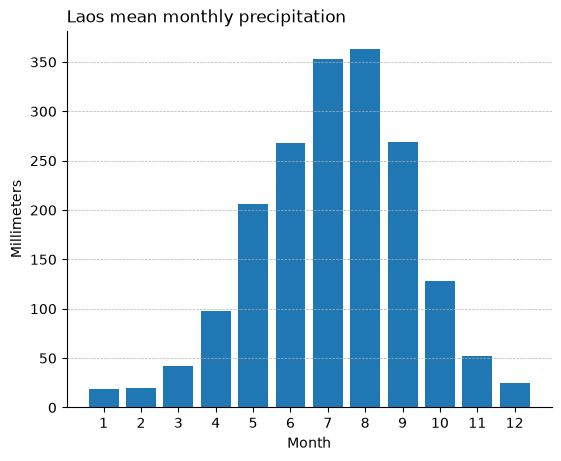

In [7]:
laos = precipitation.xs("LAO", level="country_code")
climatology = laos.groupby(laos.index.month)["precip"].mean()

figure, axis = plt.subplots(figsize=(5.5, 4.5))
axis.bar(climatology.index, climatology, color=PALETTE["primary"])
axis.set_title("Laos mean monthly precipitation", loc="left")
axis.set_xlabel("Month")
axis.set_ylabel("Millimeters")
axis.set_xticks(range(1, 13))

plt.show()

## Gotchas

*A country smaller than a grid cell still gets a reading.* Cells are one degree, roughly 111 km,
and the weighting credits a country with the share of each cell it covers rather than asking which
cells have a center inside it. Singapore, Malta, Bahrain and sixty-odd others would otherwise have
no precipitation at all.

*The resolution is the cell, not the country.* Laos is 17 cells and Cambodia 16, so a country's
series carries about that many independent numbers however finely it is subdivided afterwards.

*Most of the record rests on almost no gauges.* Over half of all country-months average under one
station per cell, and Laos runs from 0.00 in the 1890s to 2.00 in the 1990s and back to 0.96 in the
2020s. A trend fitted across the record picks up that curve as well as the weather.

*A zero gauge count is not a missing value.* A cell with no station still carries precipitation,
interpolated from its neighbours, and about two thirds of measured cells are in that position.

*It is monthly, and everything else here is annual.* Joining this frame onto the country-year panel
means summing to annual totals first. Summing a partial year reads as a drought.

*Two products are stitched, and they are not the same instrument.* The gauge analysis to 2020 is
built from far more stations than the near-real-time monitoring product that follows it. A
discontinuity at the 2020 boundary is a change of station network, not of climate.

*The index level is `country_code`, and HadCRUT5 calls the same thing `ISO`.* Joining the two means
renaming one. Nothing enforces the convention across loaders.

*`products` is part of the cache key.* `coverage_of` turns the products you pass into the span in
the cache filename, so loading a subset builds a second entry rather than reusing the first.

*Monitoring years are whole calendar years only.* `MONITORING_END` is a hardcoded 2025, so the
series stops at a year boundary rather than at the last published month. Extending the record means
editing that constant.

*DWD writes its dates in a unit string CF does not define.* The monitoring files carry
`day as %Y%m%d.%f`, so xarray hands the time axis back undecoded and the loader parses it itself.